In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn import metrics

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [4]:
def regression_metrics(y_true, y_pred):

    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    r2 = metrics.r2_score(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = 100 * mae / np.average(y_true)

    return {
        "r2": r2,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "mape": mape
    }

In [5]:
datasets = {
    "7d_no_info": pd.read_csv("qDiario_7d_no_info.csv"),
    "7d_info": pd.read_csv("qDiario_7d_info.csv"),
    "14d_no_info": pd.read_csv("qDiario_14d_no_info.csv"),
    "14d_info": pd.read_csv("qDiario_14d_info.csv")
}

In [6]:
def prepare_data(df, target_col="m3(t)"):

    df = df.dropna().copy()

    if "Fecha" in df.columns:
        df["Fecha"] = pd.to_datetime(df["Fecha"])
        dates = df["Fecha"]
    else:
        dates = pd.to_datetime(df.index)

    df_numeric = df.select_dtypes(include=[np.number])

    X = df_numeric.drop(columns=[target_col])
    y = df_numeric[target_col]

    split_idx = int(len(df) * 0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    dates_train = dates.iloc[:split_idx]
    dates_test = dates.iloc[split_idx:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y, dates_train, dates_test

In [7]:
def build_mlp_hp(input_dim, units1, units2, activation):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(int(units1), activation=activation),
        layers.Dropout(0.2),
        layers.Dense(int(units2), activation=activation),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse")

    return model

In [8]:
param_grid = [
    {"units1": 128, "units2": 64, "batch": 32, "activation": "relu"},
    {"units1": 128, "units2": 64, "batch": 64, "activation": "relu"},
    {"units1": 256, "units2": 128, "batch": 64, "activation": "relu"},
    {"units1": 256, "units2": 128, "batch": 64, "activation": "relu"},
    {"units1": 128, "units2": 64, "batch": 32, "activation": "tanh"},
    {"units1": 128, "units2": 64, "batch": 32, "activation": "elu"},
]

In [9]:
def cross_validate_mlp_hp(X_train, y_train, params, n_splits=5):

    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []

    for train_idx, val_idx in tscv.split(X_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = build_mlp_hp(
            X_train.shape[1],
            params["units1"],
            params["units2"],
            params["activation"]
        )

        model.fit(
            X_tr, y_tr,
            epochs=80,
            batch_size=params["batch"],
            verbose=0
        )

        y_pred = model.predict(X_val, verbose=0)

        scores.append(regression_metrics(y_val, y_pred)["rmse"])

    return np.mean(scores)

In [10]:
def cross_validate_mlp_ts(X_train, y_train, best_params, n_splits=10):

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

        print(f"Fold {fold+1}")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = build_mlp_hp(
            X_train.shape[1],
            best_params["units1"],
            best_params["units2"],
            best_params["activation"]
        )

        model.fit(
            X_tr, y_tr,
            epochs=40,
            batch_size=best_params["batch"],
            verbose=0
        )

        y_pred = model.predict(X_val, verbose=0)

        metrics_dict = regression_metrics(y_val, y_pred)
        fold_metrics.append(metrics_dict)

        print(f"  RMSE: {metrics_dict['rmse']:.4f} | MAE: {metrics_dict['mae']:.4f} | MAPE: {metrics_dict['mape']:.2f}")

    return fold_metrics

In [11]:
def train_and_predict_train_test_mlp(X_train, y_train, X_test, y_test, scaler_y, best_params):

    model = build_mlp_hp(
        X_train.shape[1],
        best_params["units1"],
        best_params["units2"],
        best_params["activation"]
    )

    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=best_params["batch"],
        verbose=0
    )

    y_train_pred = model.predict(X_train, verbose=0)
    y_test_pred = model.predict(X_test, verbose=0)

    # 🔥 CLAVE: NO desescalar
    y_train_true = y_train
    y_test_true = y_test

    metrics_dict = regression_metrics(y_test_true, y_test_pred)

    return metrics_dict, y_train_true, y_train_pred, y_test_true, y_test_pred

In [12]:
def plot_train_test(dates_train, dates_test,
                    y_train_true, y_train_pred,
                    y_test_true, y_test_pred,
                    title):

    plt.figure(figsize=(14,8))

    n_ticks = 10

    # =========================
    # TRAIN
    # =========================
    plt.subplot(2,1,1)

    plt.plot(dates_train, y_train_true, color="gray", label="Real")
    plt.plot(dates_train, y_train_pred, color="red", label="Predicción")

    plt.title(f"{title} - Train (80%)")
    plt.legend(loc="upper right")

    idx = np.linspace(0, len(dates_train)-1, n_ticks, dtype=int)
    plt.xticks(dates_train.iloc[idx], rotation=45)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

    # =========================
    # TEST
    # =========================
    plt.subplot(2,1,2)

    plt.plot(dates_test, y_test_true, color="gray", label="Real")
    plt.plot(dates_test, y_test_pred, color="red", label="Predicción")

    plt.title(f"{title} - Test (20%)")
    plt.legend(loc="upper right")

    idx = np.linspace(0, len(dates_test)-1, n_ticks, dtype=int)
    plt.xticks(dates_test.iloc[idx], rotation=45)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

    plt.tight_layout()
    plt.show()

In [13]:
def plot_boxplots(folds_df):

    order = ["7d_no_info", "7d_info", "14d_no_info", "14d_info"]

    palette = {
        "7d_no_info": "#4C72B0",
        "7d_info": "#55A868",
        "14d_no_info": "#C44E52",
        "14d_info": "#8172B2"
    }

    plt.figure(figsize=(18,5))

    # =========================
    # RMSE
    # =========================
    plt.subplot(1,3,1)
    sns.boxplot(data=folds_df, x="dataset", y="rmse",order=order, hue="dataset", palette=palette, legend=False)
    plt.title("RMSE por dataset")
    plt.xlabel("")
    plt.ylabel("RMSE")

    # =========================
    # MAE
    # =========================
    plt.subplot(1,3,2)
    sns.boxplot(data=folds_df, x="dataset", y="mae",order=order, hue="dataset", palette=palette, legend=False)
    plt.title("MAE por dataset")
    plt.xlabel("")
    plt.ylabel("MAE")

    # =========================
    # MAPE
    # =========================
    plt.subplot(1,3,3)
    sns.boxplot(data=folds_df, x="dataset", y="mape",order=order, hue="dataset", palette=palette, legend=False)
    plt.title("MAPE por dataset")
    plt.xlabel("")
    plt.ylabel("MAPE (%)")

    plt.tight_layout()
    plt.show()

In [14]:
hp_results = []

df_hp = datasets["7d_info"]

X_train, _, y_train, _, _, _, _ = prepare_data(df_hp)

for params in param_grid:

    print(f"Testing: {params}")

    score = cross_validate_mlp_hp(X_train, y_train, params)

    hp_results.append({**params, "rmse": score})

hp_df = pd.DataFrame(hp_results).sort_values("rmse")
display(hp_df)

best_params = hp_df.iloc[0].to_dict()

# FIX tipos
best_params = {
    "units1": int(best_params["units1"]),
    "units2": int(best_params["units2"]),
    "batch": int(best_params["batch"]),
    "activation": best_params["activation"]
}

print("Best params:", best_params)

Testing: {'units1': 128, 'units2': 64, 'batch': 32, 'activation': 'relu'}


Testing: {'units1': 128, 'units2': 64, 'batch': 64, 'activation': 'relu'}
Testing: {'units1': 256, 'units2': 128, 'batch': 64, 'activation': 'relu'}
Testing: {'units1': 256, 'units2': 128, 'batch': 64, 'activation': 'relu'}
Testing: {'units1': 128, 'units2': 64, 'batch': 32, 'activation': 'tanh'}
Testing: {'units1': 128, 'units2': 64, 'batch': 32, 'activation': 'elu'}


,units1,units2,batch,activation,rmse
4,128,64,32,tanh,0.103167
2,256,128,64,relu,0.103699
3,256,128,64,relu,0.106184
5,128,64,32,elu,0.107358
1,128,64,64,relu,0.108705
0,128,64,32,relu,0.109558


Best params: {'units1': 128, 'units2': 64, 'batch': 32, 'activation': 'tanh'}



DATASET: 7d_no_info
Fold 1
  RMSE: 0.0964 | MAE: 0.0679 | MAPE: 15.33
Fold 2
  RMSE: 0.0673 | MAE: 0.0516 | MAPE: 22.73
Fold 3
  RMSE: 0.0946 | MAE: 0.0711 | MAPE: 21.10
Fold 4
  RMSE: 0.1248 | MAE: 0.0973 | MAPE: 17.18
Fold 5
  RMSE: 0.0835 | MAE: 0.0619 | MAPE: 15.53
Fold 6
  RMSE: 0.0899 | MAE: 0.0668 | MAPE: 40.55
Fold 7
  RMSE: 0.1387 | MAE: 0.1059 | MAPE: 20.67
Fold 8
  RMSE: 0.0883 | MAE: 0.0678 | MAPE: 19.87
Fold 9
  RMSE: 0.0706 | MAE: 0.0430 | MAPE: 25.27
Fold 10
  RMSE: 0.1395 | MAE: 0.1088 | MAPE: 27.89


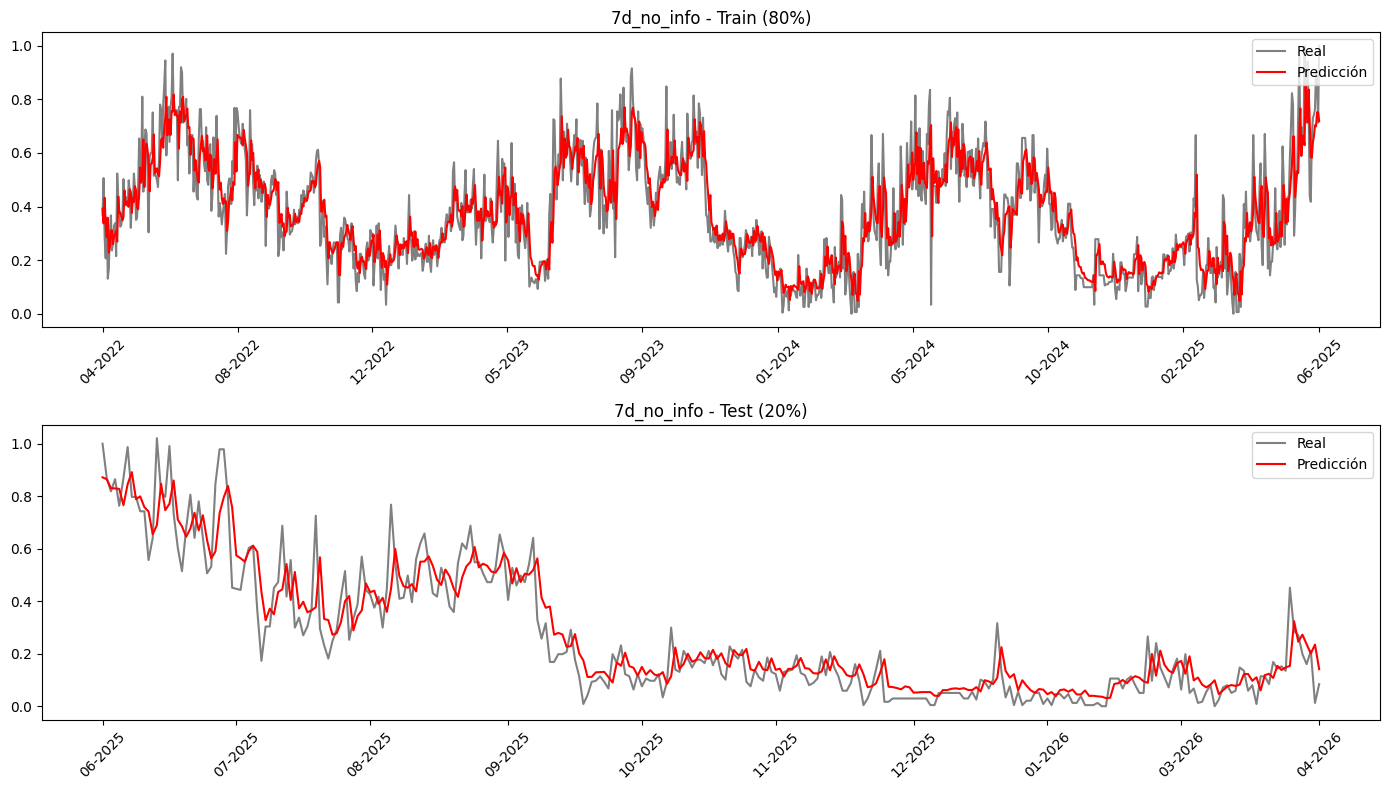


DATASET: 7d_info
Fold 1
  RMSE: 0.0996 | MAE: 0.0818 | MAPE: 18.45
Fold 2
  RMSE: 0.0770 | MAE: 0.0601 | MAPE: 26.50
Fold 3
  RMSE: 0.0981 | MAE: 0.0785 | MAPE: 23.30
Fold 4
  RMSE: 0.1299 | MAE: 0.1026 | MAPE: 18.12
Fold 5
  RMSE: 0.0851 | MAE: 0.0613 | MAPE: 15.37
Fold 6
  RMSE: 0.0966 | MAE: 0.0796 | MAPE: 48.25
Fold 7
  RMSE: 0.1324 | MAE: 0.0995 | MAPE: 19.41
Fold 8
  RMSE: 0.0888 | MAE: 0.0690 | MAPE: 20.23
Fold 9
  RMSE: 0.0745 | MAE: 0.0519 | MAPE: 30.50
Fold 10
  RMSE: 0.1372 | MAE: 0.1081 | MAPE: 27.71


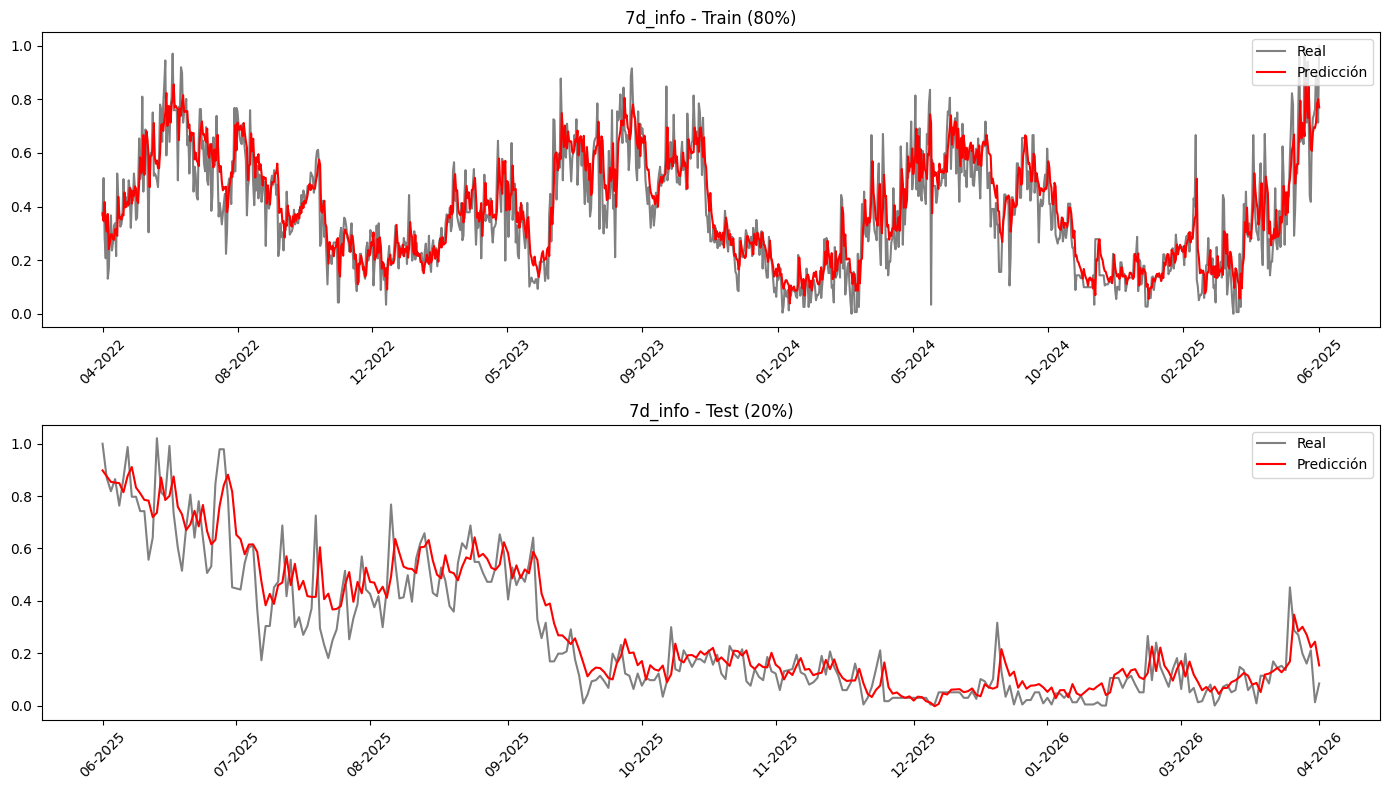


DATASET: 14d_no_info
Fold 1
  RMSE: 0.1155 | MAE: 0.0853 | MAPE: 19.36
Fold 2
  RMSE: 0.0804 | MAE: 0.0633 | MAPE: 27.69
Fold 3
  RMSE: 0.0941 | MAE: 0.0711 | MAPE: 21.06
Fold 4
  RMSE: 0.1287 | MAE: 0.1001 | MAPE: 17.58
Fold 5
  RMSE: 0.0829 | MAE: 0.0624 | MAPE: 15.88
Fold 6
  RMSE: 0.0894 | MAE: 0.0667 | MAPE: 39.97
Fold 7
  RMSE: 0.1414 | MAE: 0.1075 | MAPE: 20.94
Fold 8
  RMSE: 0.0868 | MAE: 0.0667 | MAPE: 19.81
Fold 9
  RMSE: 0.0786 | MAE: 0.0530 | MAPE: 31.09
Fold 10
  RMSE: 0.1423 | MAE: 0.1120 | MAPE: 27.66


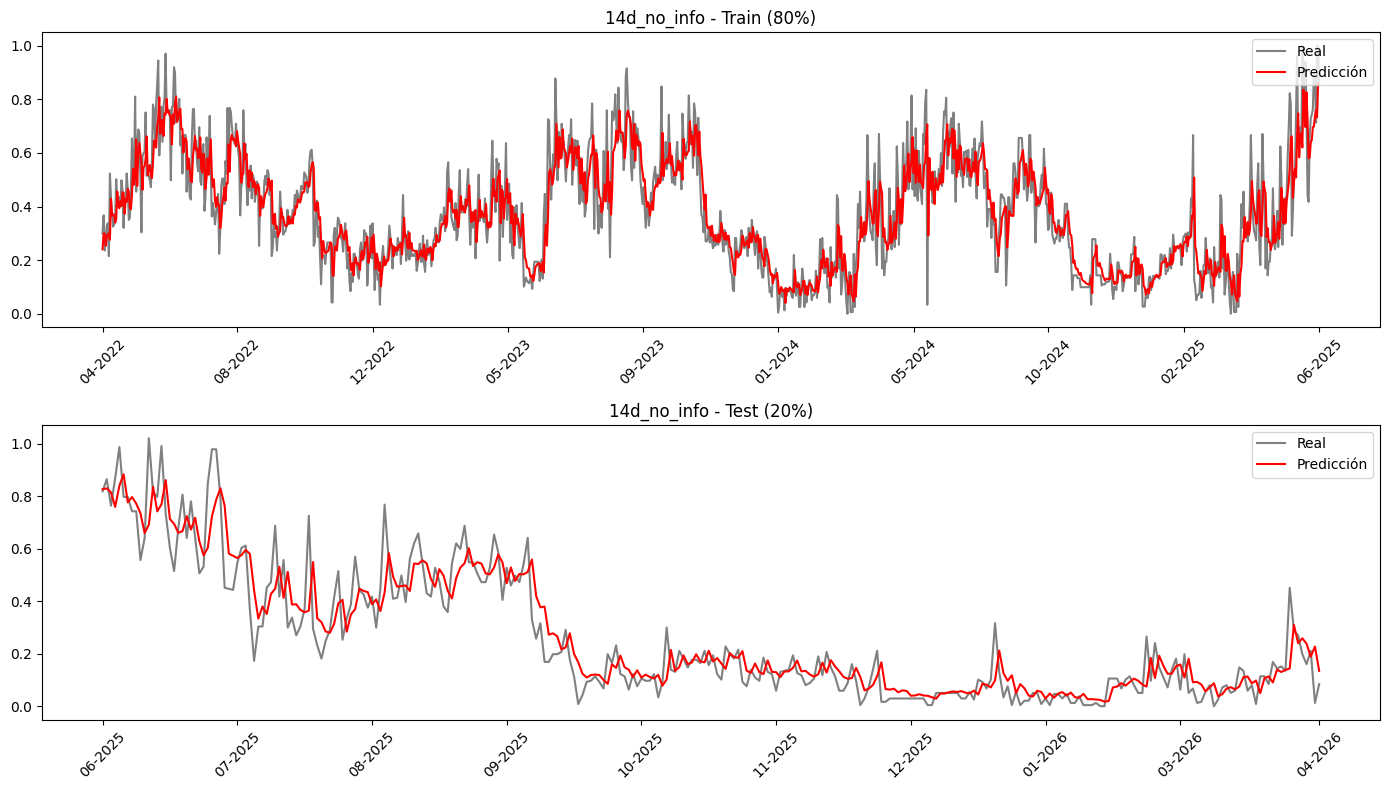


DATASET: 14d_info
Fold 1
  RMSE: 0.1075 | MAE: 0.0893 | MAPE: 20.27
Fold 2
  RMSE: 0.0802 | MAE: 0.0642 | MAPE: 28.09
Fold 3
  RMSE: 0.0999 | MAE: 0.0820 | MAPE: 24.28
Fold 4
  RMSE: 0.1339 | MAE: 0.1048 | MAPE: 18.40
Fold 5
  RMSE: 0.0852 | MAE: 0.0604 | MAPE: 15.39
Fold 6
  RMSE: 0.0954 | MAE: 0.0787 | MAPE: 47.16
Fold 7
  RMSE: 0.1416 | MAE: 0.1078 | MAPE: 21.00
Fold 8
  RMSE: 0.0855 | MAE: 0.0645 | MAPE: 19.15
Fold 9
  RMSE: 0.0781 | MAE: 0.0537 | MAPE: 31.55
Fold 10
  RMSE: 0.1415 | MAE: 0.1107 | MAPE: 27.33


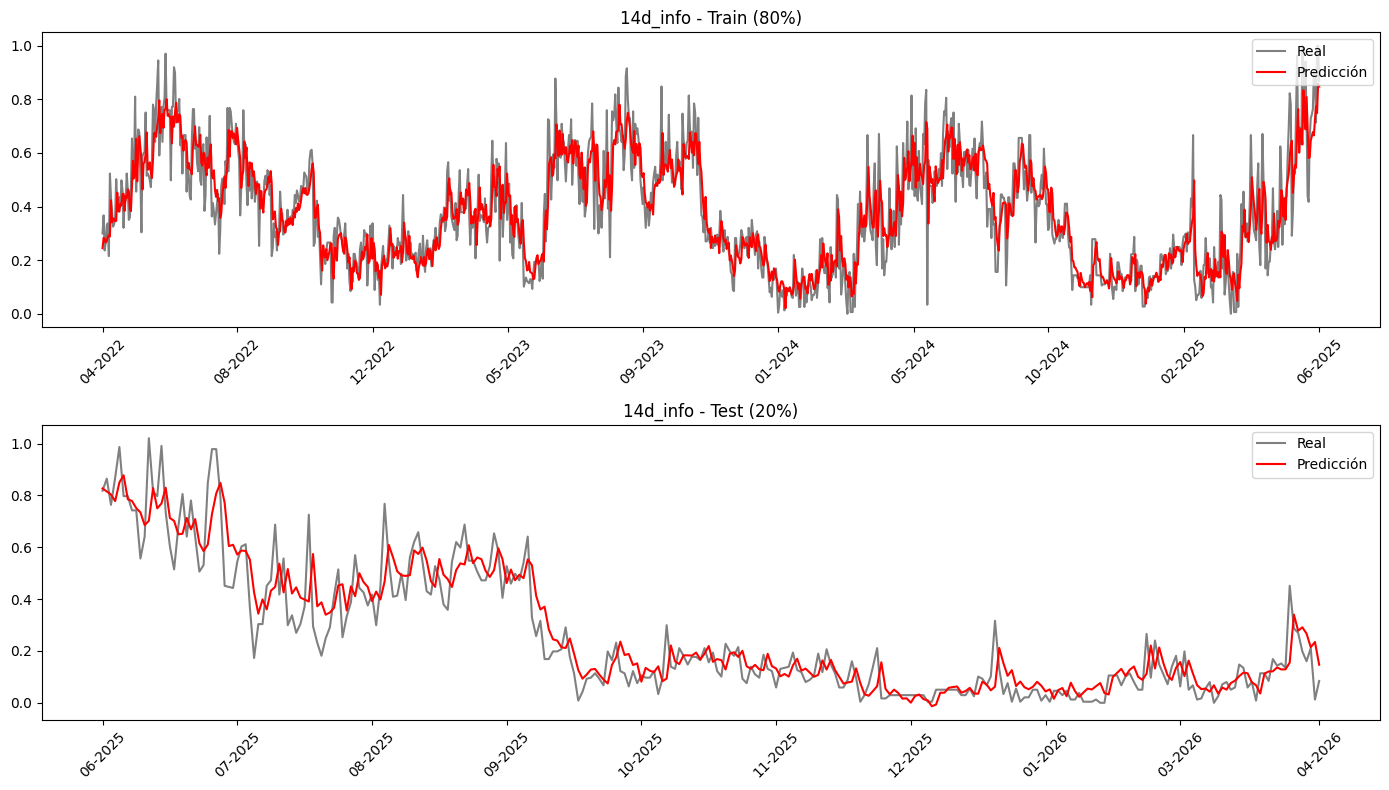

In [15]:
results = []
fold_results = []

for name, df in datasets.items():

    print(f"\n==============================")
    print(f"DATASET: {name}")
    print(f"==============================")

    X_train, X_test, y_train, y_test, scaler_y, dates_train, dates_test = prepare_data(df)

    fold_metrics = cross_validate_mlp_ts(X_train, y_train, best_params)

    for i, f in enumerate(fold_metrics):
        fold_results.append({
            "dataset": name,
            "fold": i+1,
            "rmse": f["rmse"],
            "mae": f["mae"],
            "mape": f["mape"]
        })

    avg_rmse = np.mean([f["rmse"] for f in fold_metrics])
    avg_mae = np.mean([f["mae"] for f in fold_metrics])
    avg_mape = np.mean([f["mape"] for f in fold_metrics])

    test_metrics, y_train_true, y_train_pred, y_test_true, y_test_pred = train_and_predict_train_test_mlp(
        X_train, y_train, X_test, y_test, scaler_y, best_params
    )

    results.append({
        "dataset": name,
        "cv_rmse": avg_rmse,
        "cv_mae": avg_mae,
        "cv_mape": avg_mape,
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_mape": test_metrics["mape"]
    })

    plot_train_test(
        dates_train,
        dates_test,
        y_train_true,
        y_train_pred,
        y_test_true,
        y_test_pred,
        title=name
    )

In [16]:
results_df = pd.DataFrame(results)

folds_df = pd.DataFrame(fold_results)   # 👈 AÑADIR AQUÍ

print("\n===== RESULTADOS FINALES =====")
display(results_df)

print("\n===== RESULTADOS POR FOLD =====")
display(folds_df)


===== RESULTADOS FINALES =====


,dataset,cv_rmse,cv_mae,cv_mape,test_rmse,test_mae,test_mape
0,7d_no_info,0.099353,0.074213,22.613031,0.093781,0.067884,25.605426
1,7d_info,0.101914,0.079224,24.784234,0.099484,0.073199,27.610370
2,14d_no_info,0.104005,0.078810,24.105147,0.093132,0.065650,25.201608
3,14d_info,0.104872,0.081610,25.261501,0.093951,0.067786,26.021891



===== RESULTADOS POR FOLD =====


,dataset,fold,rmse,mae,mape
0,7d_no_info,1,0.096351,0.067942,15.331366
1,7d_no_info,2,0.067323,0.051581,22.734489
2,7d_no_info,3,0.094596,0.071121,21.104674
3,7d_no_info,4,0.124769,0.097288,17.182490
4,7d_no_info,5,0.083481,0.061920,15.533311
5,7d_no_info,6,0.089894,0.066844,40.546620
6,7d_no_info,7,0.138686,0.105908,20.667448
7,7d_no_info,8,0.088283,0.067757,19.873003
8,7d_no_info,9,0.070648,0.043002,25.268191
9,7d_no_info,10,0.139499,0.108770,27.888714


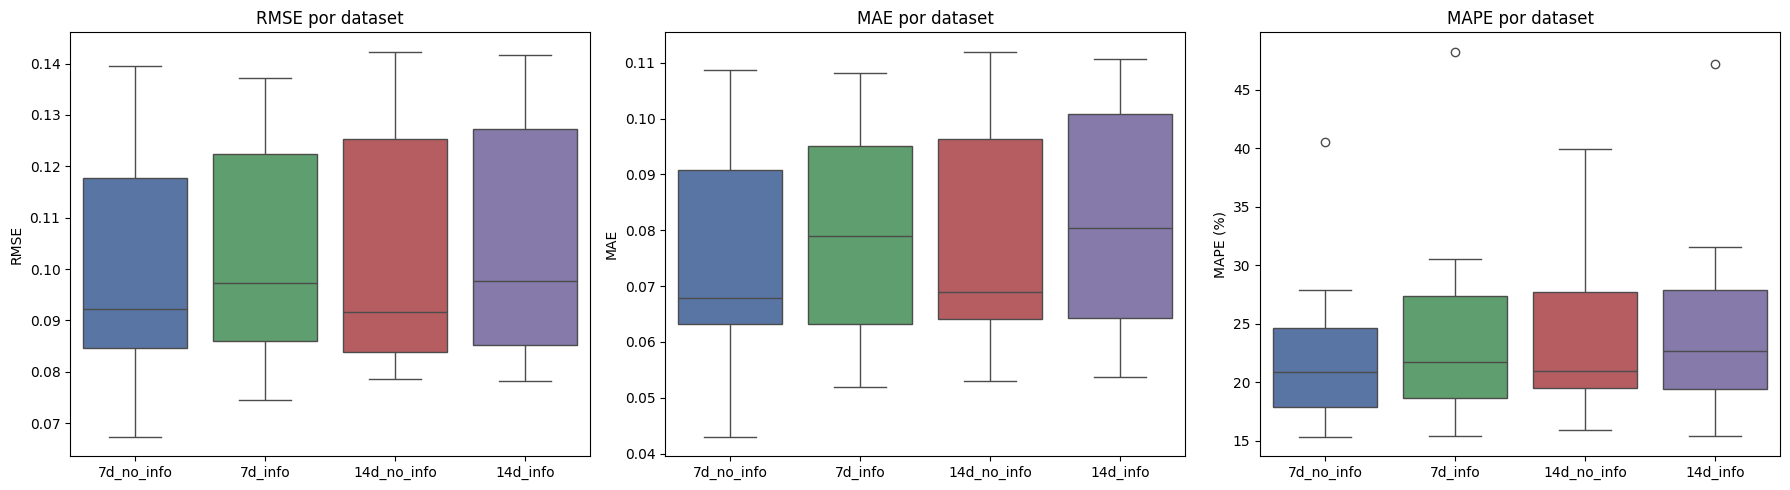

In [17]:
plot_boxplots(folds_df)

In [18]:
folds_df.to_csv("folds_mlp.csv", index=False)
results_df.to_csv("results_mlp.csv")